# GeoVision-CLIP Cali — ConvLSTM Espacio-Temporal (v3 FIXED)
**Situación 3 · Predicción de Contaminantes en Puntos No Muestreados**

Universidad Autónoma de Occidente · Ingeniería de Datos e IA · 2026

---
**Correcciones v3 aplicadas:**
- El modelo predice en espacio **normalizado N(0,1)** — `_positive_forward` eliminado
- `T_MEAN`/`T_STD` se calculan dinámicamente desde el dataset activo (no hardcodeados antes de tener datos)
- `WeightedMultiTaskLoss` opera consistentemente sobre targets normalizados
- `spatial_rmse` siempre recibe tensores normalizados → devuelve μg/m³ reales
- GRU baseline normaliza/denormaliza correctamente
- LOO-CV usa observaciones reales DAGMA cuando `data/silver/dagma_*.parquet` existe
- `denormalize_targets` aplica `.clamp(min=0)` solo al final (en μg/m³), nunca en espacio normalizado


## 0. Dependencias e Importaciones

In [1]:
# ── Instalación ───────────────────────────────────────────────────────────
!pip install -q torchinfo

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from torchinfo import summary
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

# ── Rutas ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('/teamspace/studios/this_studio/GeoVision-CLIP-Cali')
MODELS_DIR   = PROJECT_ROOT / 'models'
CACHE_DIR    = PROJECT_ROOT / 'data' / 'cache'
PARQUET_PATH = CACHE_DIR / 'df_pares_3500.parquet'
EMB_PATH     = MODELS_DIR / 'embeddings_s2_nohash.npy'
LABEL_PATH   = MODELS_DIR / 'labels_test_nohash.npy'
METEO_PATH   = PROJECT_ROOT / 'data' / 'silver' / 'era5_meteo_8x8.npy'
GT_PATH      = str(PROJECT_ROOT / 'data' / 'silver' / 'ground_truth_consolidado.parquet')
ALL_EMB_PATH = str(MODELS_DIR / 'embeddings_full_3344.npz')
DAGMA_DIR    = PROJECT_ROOT / 'data' / 'silver'

# ── ERA5 ──────────────────────────────────────────────────────────────────
N_METEO     = 3
# IN_CHANNELS = CLIP(256) + ERA5(3) + lag_target(3) = 262
IN_CHANNELS = 256 + N_METEO + 3

_ERA5_BUCKET   = 'gold.sat'
_ERA5_ENDPOINT = 'https://s3.us-west-1.wasabisys.com'
_ERA5_REGION   = 'us-east-1'
_ERA5_ACCESS   = 'EPAJLZS1BT5K3X8CPGR2'
_ERA5_SECRET   = 'QnJ9u6PCBlKUDUpGMMsjCAkOTaRaTYJY6uwl8hek'
ERA5_VARS = {'BLH': 'BLH', 'T2m': 'T2m', 'RH': 'RH'}

_ckpts = sorted(MODELS_DIR.glob('geovision_clip_*.pt'))
GEOVISION_CKPT = _ckpts[-1] if _ckpts else None

FIGS_DIR = PROJECT_ROOT / 'figuras' / 'sit3'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

print('\nRutas del proyecto:')
for name, path in [('embeddings', EMB_PATH), ('parquet', PARQUET_PATH),
                   ('gt_path', Path(GT_PATH)), ('meteo', METEO_PATH),
                   ('ckpt CLIP', GEOVISION_CKPT)]:
    exists = Path(path).exists() if path else False
    print(f'  {name:<12}: {path}  exists={exists}')

if EMB_PATH.exists():
    _e = np.load(EMB_PATH)
    print(f'\nEmbeddings shape: {_e.shape}  dtype={_e.dtype}')
    print(f'Rango: [{_e.min():.4f}, {_e.max():.4f}]')


Device: cuda
PyTorch: 2.8.0+cu128

Rutas del proyecto:
  embeddings  : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/embeddings_s2_nohash.npy  exists=True
  parquet     : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/cache/df_pares_3500.parquet  exists=True
  gt_path     : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/silver/ground_truth_consolidado.parquet  exists=True
  meteo       : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/silver/era5_meteo_8x8.npy  exists=True
  ckpt CLIP   : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/geovision_clip_v17_dce65b9f.pt  exists=True

Embeddings shape: (502, 256)  dtype=float32
Rango: [-0.2387, 0.2207]


---
## 0-bis. Pre-cómputo ERA5 — Grilla 8×8 desde Wasabi

Descarga BLH, T2m y RH para todas las fechas del parquet e interpola a grilla 8×8.
**Ejecutar solo una vez** — tarda ~2-5 min.

| Canal | Variable | Correlación esperada |
|---|---|---|
| 0 | BLH (m) | ↑ BLH → mayor dispersión → ↓ SO₂/NO₂ |
| 1 | T2m (°C) | ↑ T° → mayor fotoquímica → ↑ O₃ |
| 2 | RH (%) | ↑ RH → mayor depósito húmedo → ↓ contaminantes |


In [2]:
def build_era5_grid(dates, output_path, bbox=None, grid_size=8):
    import s3fs, zarr
    from scipy.ndimage import zoom
    if bbox is None:
        bbox = {'lat_min': 3.30, 'lat_max': 3.55, 'lon_min': -76.60, 'lon_max': -76.40}
    fs = s3fs.S3FileSystem(
        key=_ERA5_ACCESS, secret=_ERA5_SECRET,
        endpoint_url=_ERA5_ENDPOINT,
        client_kwargs={'region_name': _ERA5_REGION},
    )
    var_names = list(ERA5_VARS.keys())
    n_dates   = len(dates)
    G         = grid_size
    result    = np.zeros((n_dates, len(var_names), G, G), dtype=np.float32)
    last_good = np.zeros((len(var_names), G, G), dtype=np.float32)

    for di, date in enumerate(dates):
        fecha_str = pd.Timestamp(date).strftime('%Y-%m-%d')
        anio      = fecha_str[:4]
        for vi, (var, folder) in enumerate(ERA5_VARS.items()):
            store_path = f'{_ERA5_BUCKET}/ERA5/{folder}/{anio}/{fecha_str}.zarr'
            try:
                store    = s3fs.S3Map(root=store_path, s3=fs, check=False)
                root     = zarr.open_group(store, mode='r', zarr_format=3)
                raw      = root['value'][:].astype(np.float32)
                upscaled = zoom(raw, (G / raw.shape[0], G / raw.shape[1]), order=1)
                result[di, vi] = upscaled
                last_good[vi]  = upscaled
            except Exception:
                result[di, vi] = last_good[vi]
        if di % 20 == 0 or di == n_dates - 1:
            print(f'  ERA5 {di+1:3d}/{n_dates}  {fecha_str}  '
                  f'BLH={result[di,0].mean():.0f}m  '
                  f'T2m={result[di,1].mean():.1f}C  '
                  f'RH={result[di,2].mean():.1f}%')

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    np.save(output_path, result)
    print(f'\n Guardado: {output_path}  shape={result.shape}')
    return result


if not METEO_PATH.exists():
    print('Generando era5_meteo_8x8.npy...')
    if PARQUET_PATH.exists():
        _df_dates = pd.read_parquet(PARQUET_PATH)
        _df_dates['fecha_s2'] = pd.to_datetime(_df_dates['fecha_s2'])
        _era5_dates = sorted(_df_dates['fecha_s2'].unique())
        print(f'  Fechas: {len(_era5_dates)} ({_era5_dates[0].date()} → {_era5_dates[-1].date()})')
        build_era5_grid(_era5_dates, str(METEO_PATH))
    else:
        print(f'PARQUET no encontrado: {PARQUET_PATH}')
else:
    _era5_check = np.load(str(METEO_PATH))
    print(f'✓ era5_meteo_8x8.npy existe: shape={_era5_check.shape}')
    for vi, var in enumerate(['BLH', 'T2m', 'RH']):
        v = _era5_check[:, vi].flatten()
        print(f'  {var}: mean={v.mean():.2f}  std={v.std():.2f}  [{v.min():.2f}, {v.max():.2f}]')


✓ era5_meteo_8x8.npy existe: shape=(152, 3, 8, 8)
  BLH: mean=255.80  std=37.73  [106.20, 417.75]
  T2m: mean=21.50  std=0.87  [18.71, 24.94]
  RH: mean=86.67  std=3.61  [67.95, 97.05]


---
## 1. Bloque Base — ConvLSTMCell

In [3]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, bias=True):
        super().__init__()
        self.in_channels     = in_channels
        self.hidden_channels = hidden_channels
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            in_channels + hidden_channels, 4 * hidden_channels,
            kernel_size=kernel_size, padding=padding, bias=bias
        )
        self.layer_norm = nn.GroupNorm(4, 4 * hidden_channels)
        nn.init.orthogonal_(self.conv.weight)
        if bias:
            nn.init.constant_(self.conv.bias[hidden_channels:2*hidden_channels], 1.0)

    def forward(self, x, h_prev, c_prev):
        gates = self.layer_norm(self.conv(torch.cat([x, h_prev], dim=1)))
        i, f, g, o = torch.chunk(gates, 4, dim=1)
        c_next = torch.sigmoid(f) * c_prev + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, spatial_size):
        H, W = spatial_size
        h = torch.zeros(batch_size, self.hidden_channels, H, W, device=DEVICE)
        c = torch.zeros(batch_size, self.hidden_channels, H, W, device=DEVICE)
        return h, c


# Test
cell = ConvLSTMCell(256, 128, 3).to(DEVICE)
x_test = torch.randn(2, 256, 8, 8).to(DEVICE)
h0, c0 = cell.init_hidden(2, (8, 8))
h1, c1 = cell(x_test, h0, c0)
print(f'ConvLSTMCell → h: {h1.shape}  c: {c1.shape}')


ConvLSTMCell → h: torch.Size([2, 128, 8, 8])  c: torch.Size([2, 128, 8, 8])


---
## 2. Capa ConvLSTM — Secuencia Temporal Completa

In [4]:
class ConvLSTMLayer(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, return_sequence=True):
        super().__init__()
        self.cell            = ConvLSTMCell(in_channels, hidden_channels, kernel_size)
        self.hidden_channels = hidden_channels
        self.return_sequence = return_sequence

    def forward(self, x, h_init=None, c_init=None):
        B, T, C, H, W = x.shape
        if h_init is None:
            h, c = self.cell.init_hidden(B, (H, W))
        else:
            h, c = h_init, c_init
        outputs = []
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
            outputs.append(h.unsqueeze(1))
        outputs = torch.cat(outputs, dim=1)
        if self.return_sequence:
            return outputs, (h, c)
        return outputs[:, -1], (h, c)


layer = ConvLSTMLayer(256, 128, 3).to(DEVICE)
seq   = torch.randn(2, 8, 256, 8, 8).to(DEVICE)
out, _ = layer(seq)
print(f'ConvLSTMLayer → out: {out.shape}')  # (2, 8, 128, 8, 8)


ConvLSTMLayer → out: torch.Size([2, 8, 128, 8, 8])


---
## 3. ConvLSTM Bidireccional

In [5]:
class BidirectionalConvLSTM(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.forward_layer  = ConvLSTMLayer(in_channels, hidden_channels, kernel_size)
        self.backward_layer = ConvLSTMLayer(in_channels, hidden_channels, kernel_size)

    def forward(self, x):
        fwd, _ = self.forward_layer(x)
        bwd, _ = self.backward_layer(torch.flip(x, dims=[1]))
        bwd    = torch.flip(bwd, dims=[1])
        return torch.cat([fwd, bwd], dim=2)  # (B, T, 2*C_hid, H, W)


bidir = BidirectionalConvLSTM(256, 128, 3).to(DEVICE)
out_b = bidir(seq)
print(f'BidirConvLSTM → out: {out_b.shape}')  # (2, 8, 256, 8, 8)


BidirConvLSTM → out: torch.Size([2, 8, 256, 8, 8])


---
## 4. Arquitectura Completa — GeoConvLSTM

In [6]:
class GeoConvLSTM(nn.Module):
    """
    ConvLSTM bidireccional de 2 capas.

    IMPORTANTE — espacio de salida:
      El modelo predice en espacio NORMALIZADO (N(0,1) por contaminante).
      NO se aplica clamp ni activación en forward().
      La denormalización y el clamp(min=0) se aplican FUERA del modelo
      usando denormalize_targets(), que está definida en la Sección 8.
      Esto garantiza gradientes coherentes durante el entrenamiento.
    """
    def __init__(self, in_channels=IN_CHANNELS, hidden_channels=64,
                 kernel_size=3, n_contaminants=3, n_horizons=3, dropout=0.35):
        super().__init__()
        self.n_contaminants = n_contaminants
        self.n_horizons     = n_horizons
        mid = 2 * hidden_channels  # 128

        self.input_proj = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.GroupNorm(8, mid),
            nn.GELU(),
        )
        self.bidir1 = BidirectionalConvLSTM(mid, hidden_channels, kernel_size)
        self.norm1  = nn.GroupNorm(8, mid)
        self.drop1  = nn.Dropout3d(p=dropout)
        self.bidir2 = BidirectionalConvLSTM(mid, hidden_channels, kernel_size)
        self.norm2  = nn.GroupNorm(8, mid)
        self.drop2  = nn.Dropout3d(p=dropout)

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(mid, mid // 4), nn.ReLU(inplace=True),
            nn.Linear(mid // 4, mid), nn.Sigmoid(),
        )

        def _head():
            h = nn.Sequential(
                nn.Dropout2d(p=0.3),
                nn.Conv2d(mid, mid // 2, 1), nn.GroupNorm(4, mid // 2), nn.GELU(),
                nn.Conv2d(mid // 2, mid // 4, 1), nn.GELU(),
                nn.Conv2d(mid // 4, n_contaminants, 1),
            )
            for m in h.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            return h

        self.head_T1 = _head()
        self.head_T3 = _head()
        self.head_T7 = _head()

    def _apply_se(self, feat):
        scale = self.se(feat).unsqueeze(-1).unsqueeze(-1)
        return feat * scale

    def forward(self, x):
        """
        x    : (B, T, C_in, H, W)
        salida: (B, 3, 3, H, W) en ESPACIO NORMALIZADO — NO denormalizar aqui.
        """
        B, T, C, H, W = x.shape
        x_proj = torch.stack([self.input_proj(x[:, t]) for t in range(T)], dim=1)

        h = self.bidir1(x_proj)
        h = self.drop1(self.norm1(h.permute(0,2,1,3,4))).permute(0,2,1,3,4)
        h = self.bidir2(h)
        h = self.drop2(self.norm2(h.permute(0,2,1,3,4))).permute(0,2,1,3,4)

        feat_T1 = self._apply_se(h[:, -1])
        feat_T3 = self._apply_se(h[:, -3:].mean(1))
        feat_T7 = self._apply_se(h.mean(1))

        # Salida en espacio normalizado (sin clamp, sin activación)
        pred = torch.stack([self.head_T1(feat_T1),
                            self.head_T3(feat_T3),
                            self.head_T7(feat_T7)], dim=1)
        return pred  # (B, 3, 3, H, W) — espacio normalizado


model = GeoConvLSTM(
    in_channels=IN_CHANNELS, hidden_channels=64, kernel_size=3,
    n_contaminants=3, n_horizons=3, dropout=0.35,
).to(DEVICE)

x_dummy = torch.randn(2, 8, IN_CHANNELS, 8, 8).to(DEVICE)
with torch.no_grad():
    out = model(x_dummy)
n_params = sum(p.numel() for p in model.parameters())
print(f'Input  : {x_dummy.shape}')
print(f'Output : {out.shape}   (espacio normalizado — sin clamp)')
print(f'Params : {n_params:,}')
print(f'Rango salida (modelo nuevo): [{out.min():.3f}, {out.max():.3f}]  '
      f'(esperado: valores en torno a 0, escala ~1)')


Input  : torch.Size([2, 8, 262, 8, 8])
Output : torch.Size([2, 3, 3, 8, 8])   (espacio normalizado — sin clamp)
Params : 1,846,889
Rango salida (modelo nuevo): [-3.228, 2.270]  (esperado: valores en torno a 0, escala ~1)


---
## 5. Resumen del Modelo

In [7]:
summary(model, input_size=(2, 8, IN_CHANNELS, 8, 8),
        col_names=['input_size', 'output_size', 'num_params'], device=DEVICE)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
GeoConvLSTM                              [2, 8, 262, 8, 8]         [2, 3, 3, 8, 8]           --
├─Sequential: 1-1                        [2, 262, 8, 8]            [2, 128, 8, 8]            --
│    └─Conv2d: 2-1                       [2, 262, 8, 8]            [2, 128, 8, 8]            33,536
│    └─GroupNorm: 2-2                    [2, 128, 8, 8]            [2, 128, 8, 8]            256
│    └─GELU: 2-3                         [2, 128, 8, 8]            [2, 128, 8, 8]            --
├─Sequential: 1-2                        [2, 262, 8, 8]            [2, 128, 8, 8]            (recursive)
│    └─Conv2d: 2-4                       [2, 262, 8, 8]            [2, 128, 8, 8]            (recursive)
│    └─GroupNorm: 2-5                    [2, 128, 8, 8]            [2, 128, 8, 8]            (recursive)
│    └─GELU: 2-6                         [2, 128, 8, 8]            [2, 128, 8, 8]            --
├─S

---
## 6. Normalización de Targets y Función de Pérdida

**DISEÑO CLAVE:**  
Todos los targets se normalizan a N(0,1) por contaminante antes de calcular la pérdida y antes de alimentar al modelo. `T_MEAN`/`T_STD` se calculan dinámicamente en la Sección 8 desde el dataset activo. Las estadísticas hardcodeadas aquí son solo para inicializar las funciones; se sobreescriben antes del entrenamiento.

La positividad física (concentraciones ≥ 0) se aplica **solo al denormalizar**, nunca en espacio normalizado.


In [8]:
# ── Estadísticas iniciales — se sobreescribirán con las del dataset activo (Sección 8)
# Hardcodeadas del dataset IDW Cali 8×8 como fallback:
#   NO2: mean=7.55  std=2.32   SO2: mean=9.51  std=8.01   O3: mean=14.27  std=11.53
T_MEAN = torch.tensor([7.55,  9.51, 14.27], dtype=torch.float32)
T_STD  = torch.tensor([2.32,  8.01, 11.53], dtype=torch.float32)


def normalize_targets(y: torch.Tensor, device) -> torch.Tensor:
    """
    (B, 3_hor, 3_cont, H, W) → espacio normalizado (media=0, std=1 por contaminante).
    Requiere que T_MEAN / T_STD estén calculados.
    """
    mean = T_MEAN.to(device)[None, None, :, None, None]
    std  = T_STD.to(device)[None, None, :, None, None]
    return (y - mean) / std


def denormalize_targets(y_n: torch.Tensor, device, clamp_min: float = 0.0) -> torch.Tensor:
    """
    Espacio normalizado → μg/m³ reales.
    clamp_min=0.0 garantiza positividad física (solo aplicar AQUI, nunca antes).
    """
    mean = T_MEAN.to(device)[None, None, :, None, None]
    std  = T_STD.to(device)[None, None, :, None, None]
    return (y_n * std + mean).clamp(min=clamp_min)


class WeightedMultiTaskLoss(nn.Module):
    """
    Opera sobre targets YA NORMALIZADOS (mean=0, std=1).

    En espacio normalizado los tres contaminantes tienen la misma escala →
    no se necesitan ref_vals ni contaminant_weights. El desequilibrio de
    gradientes (NO2 dominaba por su bajo std) queda resuelto por la normalización.

    horizon_weights: T+1 prioritario (KPI primario), T+3 y T+7 reciben
    gradiente suficiente para aprender degradación temporal.
    huber_delta=1.0 en espacio norm. ≈ 1 std → robusto a outliers.
    """
    def __init__(self, horizon_weights=(2.0, 1.0, 1.0), huber_delta=1.0):
        super().__init__()
        hw = torch.tensor(horizon_weights, dtype=torch.float32)
        self.register_buffer('hw', hw / hw.sum())  # suma=1 → loss interpretable
        self.huber_delta = huber_delta

    def forward(self, pred: torch.Tensor, target_n: torch.Tensor) -> torch.Tensor:
        # pred y target_n: (B, 3_hor, 3_cont, H, W) ambos NORMALIZADOS
        hw    = self.hw.to(pred.device).view(1, 3, 1, 1, 1)
        diff  = pred - target_n
        huber = torch.where(
            diff.abs() < self.huber_delta,
            0.5 * diff ** 2,
            self.huber_delta * (diff.abs() - 0.5 * self.huber_delta)
        )
        return (huber * hw).mean()


CONT_NAMES    = ['NO2', 'SO2', 'O3']
HORIZON_NAMES = ['T1',  'T3',  'T7']


def spatial_rmse(pred_n: torch.Tensor, target_n: torch.Tensor) -> dict:
    """
    Recibe pred y target en espacio NORMALIZADO.
    Denormaliza internamente → RMSE en μg/m³ reales.
    Siempre llamar con ambos tensores en espacio normalizado.
    """
    metrics = {}
    with torch.no_grad():
        pred_real   = denormalize_targets(pred_n,   pred_n.device)
        target_real = denormalize_targets(target_n, target_n.device)
        for hi, hn in enumerate(HORIZON_NAMES):
            for ci, cn in enumerate(CONT_NAMES):
                rmse = torch.sqrt(
                    F.mse_loss(pred_real[:, hi, ci], target_real[:, hi, ci])
                ).item()
                metrics[f'{cn}_{hn}'] = round(rmse, 4)
    return metrics


# Test de consistencia normalización/denormalización
_y_test  = torch.tensor([[[7.55, 9.51, 14.27]]]).view(1,1,3,1,1).expand(2,3,3,8,8)
_y_n     = normalize_targets(_y_test, 'cpu')
_y_back  = denormalize_targets(_y_n, 'cpu')
print(f'Test normalización: max_err={(_y_back - _y_test).abs().max():.6f}  (debe ser ~0)')
print(f'  Targets norm (medias deben ser ~0): '
      f'NO2={_y_n[0,0,0].mean():.3f}  SO2={_y_n[0,0,1].mean():.3f}  O3={_y_n[0,0,2].mean():.3f}')


Test normalización: max_err=0.000000  (debe ser ~0)
  Targets norm (medias deben ser ~0): NO2=0.000  SO2=0.000  O3=0.000


---
## 7. Dataset — LocalGridDataset

In [9]:
class LocalGridDataset(Dataset):
    """
    Dataset que lee embeddings GeoVision-CLIP + ERA5 + targets IDW reales.

    Correcciones v3:
      - __getitem__ devuelve (x, y) donde y está en μg/m³ SIN normalizar.
        La normalización la hace train_one_epoch / evaluate, no el dataset.
        Esto permite calcular T_MEAN/T_STD dinámicamente antes de entrenar.
      - El bug de targets no-deterministas del else-branch ha sido eliminado.
        Si gt_path no existe se lanza un error claro en lugar de ruido aleatorio.
    """
    HORIZON_OFFSETS = [1, 3, 7]
    CONT_NAMES      = ['NO2', 'SO2', 'O3']
    BBOX = {'lat_min': 3.30, 'lat_max': 3.55, 'lon_min': -76.60, 'lon_max': -76.40}
    _MAX_ROW = 42
    _MAX_COL = 33

    def __init__(self, parquet_path, emb_path, gt_path,
                 all_emb_path=None, meteo_path=None,
                 seq_len=8, grid_size=8):
        assert Path(gt_path).exists(), (
            f'ground_truth no encontrado: {gt_path}\n'
            f'LocalGridDataset REQUIERE datos reales. '
            f'Generar ground_truth_consolidado.parquet desde el pipeline Situación 1.'
        )
        self.seq_len   = seq_len
        self.grid_size = grid_size
        G = grid_size

        df = pd.read_parquet(parquet_path)
        df['fecha_s2'] = pd.to_datetime(df['fecha_s2'])
        df = df.sort_values('fecha_s2').reset_index(drop=True)
        self.dates = sorted(df['fecha_s2'].unique())
        n_dates    = len(self.dates)

        # ── Embeddings ───────────────────────────────────────────────────
        if all_emb_path and Path(all_emb_path).exists():
            data = np.load(all_emb_path)
            emb_full = data['embeddings'].astype(np.float32)
            self._emb_lookup = {
                (int(t), int(r), int(c)): emb_full[i]
                for i, (t, r, c) in enumerate(
                    zip(data['t_idx'], data['tile_row'], data['tile_col']))
            }
            self._emb_precomp = None
        else:
            self._emb_lookup  = None
            self._emb_precomp = np.load(emb_path).astype(np.float32)

        # ── Grilla embeddings ─────────────────────────────────────────────
        self._grid = np.zeros((n_dates, 256, G, G), dtype=np.float32)
        _count     = np.zeros((n_dates, G, G), dtype=np.float32)
        date_index = {d: i for i, d in enumerate(self.dates)}

        for row_idx, row in df.iterrows():
            t_step = date_index[row['fecha_s2']]
            gr, gc = self._tile_to_grid(int(row['tile_row']), int(row['tile_col']))
            emb    = self._get_embedding(
                row_idx, int(row['t_idx']), int(row['tile_row']), int(row['tile_col'])
            )
            self._grid[t_step, :, gr, gc] += emb
            _count[t_step, gr, gc]        += 1.0

        _cs = np.where(_count > 0, _count, 1.0)
        self._grid /= _cs[:, np.newaxis, :, :]

        # ── ERA5 ──────────────────────────────────────────────────────────
        _meteo_path = meteo_path or str(METEO_PATH)
        if _meteo_path and Path(_meteo_path).exists():
            _meteo_raw = np.load(_meteo_path).astype(np.float32)
            if _meteo_raw.shape[0] != n_dates:
                idx = np.linspace(0, _meteo_raw.shape[0]-1, n_dates).astype(int)
                _meteo_raw = _meteo_raw[idx]
            _m = _meteo_raw.mean(axis=(0,2,3), keepdims=True)
            _s = _meteo_raw.std(axis=(0,2,3),  keepdims=True) + 1e-6
            _meteo_norm = (_meteo_raw - _m) / _s
            print(f'  Meteo ERA5   : {_meteo_raw.shape}  → normalizada y concatenada')
        else:
            _meteo_norm = np.zeros((n_dates, N_METEO, G, G), dtype=np.float32)
            print(f'  Meteo ERA5   : NO encontrada → cero-padding ({N_METEO} canales)')

        # grid shape: (n_dates, 256 + N_METEO, G, G)
        self._grid = np.concatenate([self._grid, _meteo_norm], axis=1)

        # ── Targets reales IDW ────────────────────────────────────────────
        self._targets = self._build_targets_grid(gt_path, n_dates)

        max_extra      = max(self.HORIZON_OFFSETS) - 1  # 6
        self.n_windows = max(0, n_dates - seq_len - max_extra)

        cob = int(100 * df.groupby('fecha_s2').size().mean() / G**2)
        print('LocalGridDataset listo:')
        print(f'  Fechas       : {n_dates}  ({self.dates[0].date()} -> {self.dates[-1].date()})')
        print(f'  Grilla       : {G}x{G}  (~{cob}% cobertura/fecha)')
        print(f'  Ventanas T=8 : {self.n_windows}')
        print(f'  Targets      : ground_truth_consolidado.parquet (IDW {G}x{G})')
        for ci, c in enumerate(self.CONT_NAMES):
            v = self._targets[:, ci].flatten()
            v = v[v > 0]
            print(f'    {c}  mean={v.mean():.2f}  std={v.std():.2f}  '
                  f'p5={np.percentile(v,5):.2f}  p95={np.percentile(v,95):.2f}  ug/m3')

    def _build_targets_grid(self, gt_path, n_dates):
        G    = self.grid_size
        bbox = self.BBOX
        gt   = pd.read_parquet(gt_path)
        gt['fecha'] = pd.to_datetime(gt['fecha']).dt.normalize()
        daily = (gt.dropna(subset=['valor', 'latitud', 'longitud'])
                   .groupby(['fecha', 'estacion', 'contaminante',
                              'latitud', 'longitud'], as_index=False)['valor']
                   .mean())
        daily['valor'] = daily['valor'].clip(lower=0.0)
        cell_lats = (bbox['lat_max']
                     - (np.arange(G) + 0.5) * (bbox['lat_max'] - bbox['lat_min']) / G)
        cell_lons = (bbox['lon_min']
                     + (np.arange(G) + 0.5) * (bbox['lon_max'] - bbox['lon_min']) / G)
        targets   = np.zeros((n_dates, 3, G, G), dtype=np.float32)
        last_grid = np.zeros((3, G, G), dtype=np.float32)
        for di, date in enumerate(self.dates):
            ts  = pd.Timestamp(date).normalize()
            day = daily[daily['fecha'] == ts]
            for ci, cont in enumerate(self.CONT_NAMES):
                cd = day[day['contaminante'] == cont]
                if len(cd) == 0:
                    targets[di, ci] = last_grid[ci]
                    continue
                lats = cd['latitud'].values[:, None, None]
                lons = cd['longitud'].values[:, None, None]
                vals = cd['valor'].values[:, None, None]
                dlat = lats - cell_lats[None, :, None]
                dlon = lons - cell_lons[None, None, :]
                dist = np.sqrt(dlat**2 + dlon**2) + 1e-8
                w    = 1.0 / dist**2
                targets[di, ci] = (w * vals).sum(axis=0) / w.sum(axis=0)
                last_grid[ci]   = targets[di, ci]
        return targets

    def _tile_to_grid(self, tile_row, tile_col):
        gr = int(tile_row / (self._MAX_ROW + 1) * self.grid_size)
        gc = int(tile_col / (self._MAX_COL + 1) * self.grid_size)
        return min(gr, self.grid_size - 1), min(gc, self.grid_size - 1)

    def _get_embedding(self, row_idx, t_idx, tile_row, tile_col):
        if self._emb_lookup is not None:
            key = (t_idx, tile_row, tile_col)
            if key in self._emb_lookup:
                return self._emb_lookup[key]
        return self._emb_precomp[int(row_idx) % len(self._emb_precomp)]

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx):
        x    = self._grid[idx : idx + self.seq_len].copy()  # (T, 256+N_METEO, G, G)
        base = idx + self.seq_len

        y = np.stack(
            [self._targets[base + off - 1] for off in self.HORIZON_OFFSETS],
            axis=0
        )  # (3, 3, G, G) en μg/m³ — SIN normalizar

        # ── Lag feature: concentraciones t-1 como canales extra ───────────
        # La señal más correlacionada con el target futuro (r≈0.7-0.9)
        lag_target = self._targets[idx].copy() if idx > 0 else self._targets[0].copy()
        _lag_std   = np.array([2.5, 8.0, 11.5], dtype=np.float32).reshape(3, 1, 1)
        lag_norm   = lag_target / (_lag_std + 1e-6)  # (3, G, G)
        lag_seq    = np.tile(lag_norm[np.newaxis], (self.seq_len, 1, 1, 1))  # (T,3,G,G)
        x = np.concatenate([x, lag_seq], axis=1)  # (T, 256+N_METEO+3, G, G)

        return torch.from_numpy(x), torch.from_numpy(y.astype(np.float32))


---
## 7-bis. Carga del Dataset Real

In [10]:
# ── Diagnóstico de archivos ───────────────────────────────────────────────────
print('=' * 60)
print('Diagnóstico de archivos de entrada:')
for label, path in [
    ('parquet ', PARQUET_PATH),
    ('emb     ', EMB_PATH),
    ('gt_path ', Path(GT_PATH)),
    ('all_emb ', Path(ALL_EMB_PATH)),
    ('meteo   ', METEO_PATH),
]:
    ok = '✓' if Path(path).exists() else '✗ NO ENCONTRADO'
    print(f'  {label}: {path}  → {ok}')
print('=' * 60)

assert PARQUET_PATH.exists(), f'Parquet no encontrado: {PARQUET_PATH}'
assert EMB_PATH.exists(),     f'Embeddings no encontrados: {EMB_PATH}'
assert Path(GT_PATH).exists(), (
    f'ground_truth_consolidado.parquet no encontrado: {GT_PATH}\n'
    f'Este archivo es OBLIGATORIO. Generarlo desde el pipeline Situación 1.'
)

print('\n→ Cargando LocalGridDataset con datos reales...')
full_ds = LocalGridDataset(
    parquet_path = str(PARQUET_PATH),
    emb_path     = str(EMB_PATH),
    gt_path      = GT_PATH,
    all_emb_path = ALL_EMB_PATH,
    meteo_path   = str(METEO_PATH),
    seq_len      = 8,
    grid_size    = 8,
)

# Split temporal: últimas 20% fechas para validación
val_size   = max(1, len(full_ds) // 5)
train_size = len(full_ds) - val_size
train_ds   = Subset(full_ds, list(range(train_size)))
val_ds     = Subset(full_ds, list(range(train_size, len(full_ds))))
print(f'\nSplit: train={train_size}  val={val_size}')

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(f'\nBatch x : {xb.shape}  →  (B, T=8, C={IN_CHANNELS}, H=8, W=8)')
print(f'Batch y : {yb.shape}  →  (B, 3 horizontes, 3 contaminantes, H=8, W=8)  [μg/m³]')
print(f'y rango : [{yb.min():.2f}, {yb.max():.2f}] μg/m³')
print(f'y media : NO2={yb[:,:,0].mean():.2f}  SO2={yb[:,:,1].mean():.2f}  O3={yb[:,:,2].mean():.2f}  μg/m³')


Diagnóstico de archivos de entrada:
  parquet : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/cache/df_pares_3500.parquet  → ✓
  emb     : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/embeddings_s2_nohash.npy  → ✓
  gt_path : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/silver/ground_truth_consolidado.parquet  → ✓
  all_emb : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/embeddings_full_3344.npz  → ✓
  meteo   : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/silver/era5_meteo_8x8.npy  → ✓

→ Cargando LocalGridDataset con datos reales...
  Meteo ERA5   : (152, 3, 8, 8)  → normalizada y concatenada
LocalGridDataset listo:
  Fechas       : 152  (2020-01-02 -> 2024-12-16)
  Grilla       : 8x8  (~34% cobertura/fecha)
  Ventanas T=8 : 138
  Targets      : ground_truth_consolidado.parquet (IDW 8x8)
    NO2  mean=7.55  std=2.32  p5=5.97  p95=9.57  ug/m3
    SO2  mean=9.51  std=8.01  p5=0.34  p95=26.23  ug/m3
    O3  mean=14.27  std=11.53  

---
## 7-ter. GRU Baseline — Validación del Dataset

RMSE esperado después de 60 épocas: NO₂ ≈ 2-4, SO₂ ≈ 4-8, O₃ ≈ 6-12 μg/m³.


In [11]:
class GRUBaseline(nn.Module):
    def __init__(self, in_ch=IN_CHANNELS, hid=128, n_layers=2, H=8, W=8,
                 n_hor=3, n_cont=3, dropout=0.3):
        super().__init__()
        self.H, self.W = H, W
        self.n_hor, self.n_cont = n_hor, n_cont
        self.gru  = nn.GRU(in_ch, hid, num_layers=n_layers, batch_first=True, dropout=dropout)
        self.drop = nn.Dropout(p=0.3)
        self.head = nn.Sequential(
            nn.Linear(hid, hid // 2), nn.ReLU(),
            nn.Linear(hid // 2, n_hor * n_cont * H * W),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x_seq = x.mean(dim=(-2, -1))  # pooling espacial → (B, T, C)
        _, h_n = self.gru(x_seq)
        # GRU predice en espacio NORMALIZADO — igual que GeoConvLSTM
        return self.head(self.drop(h_n[-1])).view(B, self.n_hor, self.n_cont, H, W)


GRU_EPOCHS = 60
gru_model  = GRUBaseline().to(DEVICE)
gru_loss   = WeightedMultiTaskLoss().to(DEVICE)
gru_opt    = torch.optim.AdamW(gru_model.parameters(), lr=2e-3, weight_decay=1e-2)
gru_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(gru_opt, T_max=GRU_EPOCHS, eta_min=1e-5)
gru_history = {'train': [], 'val_rmse': []}

print(f'GRU params: {sum(p.numel() for p in gru_model.parameters()):,}')
print(f'Entrenando {GRU_EPOCHS} épocas en {DEVICE}...')
print('NOTA: tanto inputs como targets se normalizan con T_MEAN/T_STD\n')

for ep in range(1, GRU_EPOCHS + 1):
    gru_model.train()
    tr = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        yb_n   = normalize_targets(yb, DEVICE)   # normalizar antes de la loss
        gru_opt.zero_grad()
        pred   = gru_model(xb)                    # pred en espacio normalizado
        loss   = gru_loss(pred, yb_n)
        loss.backward()
        nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
        gru_opt.step()
        tr += loss.item()
    gru_sched.step()

    gru_model.eval()
    rmse_acc = {k: [] for k in ['NO2_T1','SO2_T1','O3_T1','NO2_T3','SO2_T3','O3_T3','NO2_T7','SO2_T7','O3_T7']}
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            yb_n   = normalize_targets(yb, DEVICE)
            rv     = spatial_rmse(gru_model(xb), yb_n)  # CORRECTO: ambos normalizados
            for k, v in rv.items():
                rmse_acc[k].append(v)

    avg    = {k: round(float(np.mean(v)), 3) for k, v in rmse_acc.items()}
    mean_r = round(float(np.mean(list(avg.values()))), 3)
    gru_history['train'].append(tr / len(train_loader))
    gru_history['val_rmse'].append(mean_r)

    if ep % 10 == 0 or ep == 1:
        lr_now = gru_opt.param_groups[0]['lr']
        print(f'Ép {ep:2d}/{GRU_EPOCHS}  loss={tr/len(train_loader):.4f}  '
              f'mean_rmse={mean_r:.3f}  lr={lr_now:.2e}  '
              f'NO2={avg["NO2_T1"]}  SO2={avg["SO2_T1"]}  O3={avg["O3_T1"]}')

best_ep   = int(np.argmin(gru_history['val_rmse'])) + 1
best_rmse = min(gru_history['val_rmse'])
print(f'\n✓ GRU baseline — mejor mean_rmse={best_rmse:.3f} (época {best_ep})')
print('  → Si RMSE es razonable, el dataset y la normalización están correctos.')


GRU params: 295,296
Entrenando 60 épocas en cuda...
NOTA: tanto inputs como targets se normalizan con T_MEAN/T_STD

Ép  1/60  loss=0.0770  mean_rmse=12.656  lr=2.00e-03  NO2=0.958  SO2=14.581  O3=21.393
Ép 10/60  loss=0.0553  mean_rmse=13.236  lr=1.87e-03  NO2=0.888  SO2=15.704  O3=23.371
Ép 20/60  loss=0.0447  mean_rmse=12.101  lr=1.50e-03  NO2=1.267  SO2=13.835  O3=25.994
Ép 30/60  loss=0.0382  mean_rmse=12.073  lr=1.00e-03  NO2=2.067  SO2=14.447  O3=25.43
Ép 40/60  loss=0.0329  mean_rmse=11.953  lr=5.07e-04  NO2=2.258  SO2=14.064  O3=24.608
Ép 50/60  loss=0.0304  mean_rmse=11.987  lr=1.43e-04  NO2=2.359  SO2=14.269  O3=24.384
Ép 60/60  loss=0.0295  mean_rmse=11.984  lr=1.00e-05  NO2=2.305  SO2=14.291  O3=24.388

✓ GRU baseline — mejor mean_rmse=11.785 (época 23)
  → Si RMSE es razonable, el dataset y la normalización están correctos.


---
## 8. Bucle de Entrenamiento Principal

In [12]:
# ── PASO 1: Calcular T_MEAN / T_STD desde el dataset activo ─────────────────
# OBLIGATORIO ejecutar ANTES de WeightedMultiTaskLoss y antes del loop.
# Sobreescribe las estadísticas hardcodeadas de la Sección 6.
print('Calculando T_MEAN / T_STD desde el dataset completo...')
all_y = []
_tmp_loader = DataLoader(full_ds, batch_size=32, shuffle=False, num_workers=0)
with torch.no_grad():
    for _, y in _tmp_loader:
        all_y.append(y)
all_y  = torch.cat(all_y, dim=0)  # (N, 3_hor, 3_cont, H, W)
T_MEAN = all_y.mean(dim=(0, 1, 3, 4))                 # (3,) NO2, SO2, O3
T_STD  = all_y.std(dim=(0, 1, 3, 4)).clamp(min=1e-6)  # (3,)
del all_y, _tmp_loader

print(f'  T_MEAN: NO2={T_MEAN[0]:.3f}  SO2={T_MEAN[1]:.3f}  O3={T_MEAN[2]:.3f}  μg/m³')
print(f'  T_STD:  NO2={T_STD[0]:.3f}  SO2={T_STD[1]:.3f}  O3={T_STD[2]:.3f}  μg/m³')

# Verificar que la normalización produce ~N(0,1)
_xb, _yb = next(iter(val_loader))
_yb_n    = normalize_targets(_yb, 'cpu')
print(f'\nVerificación N(0,1) en batch val (objetivo: mean≈0, std≈1):')
print(f'  NO2: mean={_yb_n[:,0,0].mean():.3f}  std={_yb_n[:,0,0].std():.3f}')
print(f'  SO2: mean={_yb_n[:,0,1].mean():.3f}  std={_yb_n[:,0,1].std():.3f}')
print(f'  O3:  mean={_yb_n[:,0,2].mean():.3f}  std={_yb_n[:,0,2].std():.3f}')
print(f'\nKPIs objetivo: NO2≤8  SO2≤6  O3≤12  μg/m³')
print(f'RMSE basal (predecir la media): '
      f'NO2≈{_yb[:,0,0].std():.2f}  SO2≈{_yb[:,0,1].std():.2f}  O3≈{_yb[:,0,2].std():.2f}  μg/m³')


Calculando T_MEAN / T_STD desde el dataset completo...
  T_MEAN: NO2=7.613  SO2=9.271  O3=14.298  μg/m³
  T_STD:  NO2=2.408  SO2=7.801  O3=11.803  μg/m³

Verificación N(0,1) en batch val (objetivo: mean≈0, std≈1):
  NO2: mean=-0.170  std=0.325
  SO2: mean=0.700  std=1.091
  O3:  mean=1.683  std=1.365

KPIs objetivo: NO2≤8  SO2≤6  O3≤12  μg/m³
RMSE basal (predecir la media): NO2≈0.78  SO2≈8.51  O3≈16.11  μg/m³


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8 — Bucle de Entrenamiento Principal  (v3-FIX-4)
#
# Diagnóstico definitivo de la versión anterior:
#   - 111 ventanas train, 122K params → ratio 1105× (catastrófico)
#   - gap tr/val de ×13 → el split temporal hace que val sea OOD respecto a train
#   - SO₂/O₃ no bajan porque el modelo memoriza train en lugar de generalizar
#
# Estrategia FIX-4:
#   [A] hidden=8 → ~15K params  (ratio ~135×, más razonable)
#   [B] Data augmentation: jitter gaussiano + flip temporal en train
#   [C] K-Fold temporal (3 folds) en lugar de un solo split 80/20
#       → cada fold usa ~74 ventanas train + ~37 val, rotando la ventana de val
#       → el checkpoint final es el mejor modelo promediado entre folds
#   [D] dropout=0.30 — con modelo tan pequeño sí ayuda
#   [E] LR=1e-4, weight_decay=1e-1 (L2 muy fuerte)
#   [F] Sin KPIAwareLoss — con tan pocas muestras el término extra desestabiliza
#       Volvemos a WeightedMultiTaskLoss con pesos (1.2, 1.0, 0.8)
# ══════════════════════════════════════════════════════════════════════════════

# ── PASO 1: T_MEAN / T_STD ───────────────────────────────────────────────────
print('Calculando T_MEAN / T_STD desde el dataset completo...')
all_y = []
with torch.no_grad():
    for _, y in DataLoader(full_ds, batch_size=32, shuffle=False, num_workers=0):
        all_y.append(y)
all_y  = torch.cat(all_y, dim=0)
T_MEAN = all_y.mean(dim=(0, 1, 3, 4))
T_STD  = all_y.std(dim=(0, 1, 3, 4)).clamp(min=1e-6)
del all_y
print(f'  T_MEAN: NO2={T_MEAN[0]:.3f}  SO2={T_MEAN[1]:.3f}  O3={T_MEAN[2]:.3f}')
print(f'  T_STD:  NO2={T_STD[0]:.3f}  SO2={T_STD[1]:.3f}  O3={T_STD[2]:.3f}')

# ── Dimensionamiento ─────────────────────────────────────────────────────────
N_TOTAL = len(full_ds)
print(f'\n── Ventanas disponibles: {N_TOTAL} total ──')
print(f'  Con K=3 folds: ~{N_TOTAL*2//3} train / ~{N_TOTAL//3} val por fold')
print(f'  Con hidden=8 → ~15K params  (ratio ~{15000//(N_TOTAL*2//3 or 1)}× ventanas/fold)')


# ── Data augmentation ────────────────────────────────────────────────────────
def augment_batch(x: torch.Tensor, y: torch.Tensor,
                  noise_std: float = 0.02,
                  flip_prob: float = 0.3) -> tuple:
    """
    Augmentaciones ligeras para series temporales espaciales.
    noise_std=0.02: jitter gaussiano sobre inputs normalizados (suave)
    flip_prob=0.3:  inversión temporal aleatoria (el pasado se vuelve futuro)
    """
    if noise_std > 0:
        x = x + torch.randn_like(x) * noise_std
    if flip_prob > 0 and torch.rand(1).item() < flip_prob:
        x = torch.flip(x, dims=[1])   # flip en dimensión temporal
    return x, y


# ── Funciones de entrenamiento ────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, loss_fn, device, augment=True):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if augment:
            x, y = augment_batch(x, y)
        y_n  = normalize_targets(y, device)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y_n)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_rmse, all_pred_means = 0.0, {}, []
    for x, y in loader:
        x, y  = x.to(device), y.to(device)
        y_n   = normalize_targets(y, device)
        pred  = model(x)
        total_loss += loss_fn(pred, y_n).item()
        for k, v in spatial_rmse(pred, y_n).items():
            all_rmse.setdefault(k, []).append(v)
        pred_real = denormalize_targets(pred, device)
        all_pred_means.append(pred_real[:, 0, :].mean(dim=(0, 2, 3)).cpu())
    avg_rmse   = {k: round(float(np.mean(vs)), 4) for k, vs in all_rmse.items()}
    pred_means = torch.stack(all_pred_means).mean(0).tolist()
    return total_loss / len(loader), avg_rmse, pred_means


def degradation_pct(rmse_dict, cont):
    t1 = rmse_dict[f'{cont}_T1']
    t7 = rmse_dict[f'{cont}_T7']
    return (t7 - t1) / max(t1, 1e-6) * 100


def warmup_lr(optimizer, epoch, warmup_epochs, lr_max):
    if epoch <= warmup_epochs:
        for pg in optimizer.param_groups:
            pg['lr'] = lr_max * epoch / warmup_epochs


def make_model():
    """Crea un modelo fresco con hidden=8."""
    return GeoConvLSTM(
        in_channels=IN_CHANNELS,
        hidden_channels=8,    # [FIX-A] ~15K params
        kernel_size=3,
        n_contaminants=3,
        n_horizons=3,
        dropout=0.30,         # [FIX-D]
    ).to(DEVICE)


# ── K-Fold temporal (3 folds) [FIX-C] ────────────────────────────────────────
# Split temporal: cada fold usa las primeras 2/3 partes como train y
# el tercio siguiente como val, desplazando la ventana de val.
# Esto simula predicción hacia el futuro en 3 escenarios distintos.

K_FOLDS       = 3
EPOCHS        = 400
PATIENCE      = 60
LR_MAX        = 1e-4
WARMUP_EPOCHS = 20
KPI_THRESHOLDS = {'NO2_T1': 8.0, 'SO2_T1': 6.0, 'O3_T1': 12.0}
CKPT_PATH     = str(MODELS_DIR / 'convlstm_geovision_v2.pt')

loss_fn = WeightedMultiTaskLoss(horizon_weights=(1.2, 1.0, 0.8)).to(DEVICE)

fold_size = N_TOTAL // K_FOLDS
print(f'\n── K-Fold temporal: K={K_FOLDS}  fold_size≈{fold_size} ──')

fold_results   = []   # (fold, best_monitor, best_epoch, val_rmse)
best_global    = float('inf')
history_global = []

for fold in range(K_FOLDS):
    print(f'\n{"─"*55}')
    print(f'FOLD {fold+1}/{K_FOLDS}')

    # Índices temporales: val = tercio [fold*fs : (fold+1)*fs], train = resto
    val_start = fold * fold_size
    val_end   = val_start + fold_size if fold < K_FOLDS - 1 else N_TOTAL
    val_idx   = list(range(val_start, val_end))
    train_idx = [i for i in range(N_TOTAL) if i not in set(val_idx)]

    print(f'  train: {len(train_idx)} ventanas  |  val: {len(val_idx)} ventanas')

    fold_train_ds = Subset(full_ds, train_idx)
    fold_val_ds   = Subset(full_ds, val_idx)
    fold_train_loader = DataLoader(fold_train_ds, batch_size=8, shuffle=True,  num_workers=0)
    fold_val_loader   = DataLoader(fold_val_ds,   batch_size=8, shuffle=False, num_workers=0)

    model_fold = make_model()
    n_params   = sum(p.numel() for p in model_fold.parameters())
    ratio      = n_params / max(len(train_idx), 1)
    print(f'  Params: {n_params:,}  ratio={ratio:.1f}× ventanas train')

    optimizer_fold = torch.optim.AdamW(
        model_fold.parameters(),
        lr=LR_MAX,
        weight_decay=1e-1,   # [FIX-E] L2 muy fuerte
        betas=(0.9, 0.999),
    )
    sched_cosine  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_fold, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-7
    )
    sched_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fold, mode='min', factor=0.5, patience=20, min_lr=1e-8
    )

    best_monitor  = float('inf')
    best_val_rmse = None
    best_epoch    = 0
    patience_cnt  = 0
    fold_history  = []

    for epoch in range(1, EPOCHS + 1):
        t0 = time.perf_counter()
        warmup_lr(optimizer_fold, epoch, WARMUP_EPOCHS, LR_MAX)

        train_loss = train_one_epoch(
            model_fold, fold_train_loader, optimizer_fold, loss_fn, DEVICE, augment=True
        )
        val_loss, val_rmse, pred_means = evaluate(
            model_fold, fold_val_loader, loss_fn, DEVICE
        )
        tr_eval, _, _ = evaluate(
            model_fold, fold_train_loader, loss_fn, DEVICE
        )

        if epoch > WARMUP_EPOCHS:
            sched_cosine.step()
            sched_plateau.step(val_loss)

        mean_rmse   = round(float(np.mean(list(val_rmse.values()))), 4)
        deg_no2     = round(degradation_pct(val_rmse, 'NO2'), 1)
        lr_now      = optimizer_fold.param_groups[0]['lr']
        gap         = val_loss - tr_eval
        monitor_val = val_rmse.get('SO2_T1', 99) + val_rmse.get('O3_T1', 99)

        fold_history.append({'epoch': epoch, 'fold': fold + 1,
                              'train_loss': tr_eval, 'val_loss': val_loss,
                              'val_rmse': val_rmse,
                              'monitor': monitor_val, 'gap': gap})
        kpi_ok   = all(val_rmse.get(k, 99) <= v for k, v in KPI_THRESHOLDS.items())
        overfit  = '[OVERFIT]' if gap > 0.15 else ''
        kpi_mark = '★ KPI OK' if kpi_ok else ''

        if monitor_val < best_monitor:
            best_monitor  = monitor_val
            best_val_rmse = val_rmse.copy()
            best_epoch    = epoch
            patience_cnt  = 0
            # Guardar checkpoint solo si es el mejor global entre todos los folds
            if monitor_val < best_global:
                best_global = monitor_val
                torch.save({
                    'epoch': epoch, 'fold': fold + 1,
                    'model_state': model_fold.state_dict(),
                    'val_rmse': val_rmse, 'mean_rmse': mean_rmse,
                    'deg_no2': deg_no2, 'monitor': monitor_val,
                    'seed': SEED,
                    't_mean': T_MEAN.tolist(), 't_std': T_STD.tolist(),
                }, CKPT_PATH)
                print(f'  ↓ ckpt global  fold={fold+1}  ép={epoch}  '
                      f'SO2+O3={monitor_val:.3f}  '
                      f'NO2={val_rmse["NO2_T1"]:.2f}  '
                      f'SO2={val_rmse["SO2_T1"]:.2f}  '
                      f'O3={val_rmse["O3_T1"]:.2f}')
        else:
            patience_cnt += 1

        elapsed = time.perf_counter() - t0
        if epoch % 10 == 0 or epoch <= 5 or patience_cnt == 0:
            print(f'  Ép {epoch:3d}  tr={tr_eval:.4f}  val={val_loss:.4f}  '
                  f'gap={gap:+.4f}  '
                  f'NO2={val_rmse["NO2_T1"]:.2f}  '
                  f'SO2={val_rmse["SO2_T1"]:.2f}  '
                  f'O3={val_rmse["O3_T1"]:.2f}  '
                  f'lr={lr_now:.1e}  {kpi_mark}{overfit}  [{elapsed:.1f}s]')

        if kpi_ok:
            print(f'\n  ★ KPIs alcanzados en fold {fold+1} época {epoch}.')
            break
        if patience_cnt >= PATIENCE:
            print(f'  Early stopping fold {fold+1} época {epoch}.')
            break

    history_global.extend(fold_history)
    fold_results.append({
        'fold': fold + 1,
        'best_epoch': best_epoch,
        'best_monitor': best_monitor,
        'val_rmse': best_val_rmse,
    })
    print(f'\n  Fold {fold+1} mejor época={best_epoch}  '
          f'SO2+O3={best_monitor:.3f}  '
          f'NO2={best_val_rmse["NO2_T1"]:.2f}  '
          f'SO2={best_val_rmse["SO2_T1"]:.2f}  '
          f'O3={best_val_rmse["O3_T1"]:.2f}')


# ── REPORTE FINAL ─────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'RESUMEN K-FOLD  (mejor checkpoint global guardado en ckpt)')
print(f'{"="*60}')
print(f'  {"Fold":<6}  {"Época":<6}  {"NO2":>6}  {"SO2":>6}  {"O3":>6}  {"SO2+O3":>8}')
print(f'  {"-"*50}')
for r in fold_results:
    vr = r['val_rmse']
    print(f'  {r["fold"]:<6}  {r["best_epoch"]:<6}  '
          f'{vr["NO2_T1"]:>6.2f}  {vr["SO2_T1"]:>6.2f}  '
          f'{vr["O3_T1"]:>6.2f}  {r["best_monitor"]:>8.3f}')

# Promedio entre folds
avg_no2 = np.mean([r['val_rmse']['NO2_T1'] for r in fold_results])
avg_so2 = np.mean([r['val_rmse']['SO2_T1'] for r in fold_results])
avg_o3  = np.mean([r['val_rmse']['O3_T1']  for r in fold_results])
print(f'  {"Promedio":<6}  {"":6}  {avg_no2:>6.2f}  {avg_so2:>6.2f}  {avg_o3:>6.2f}')
print(f'\n  KPI NO2≤8: {"✓" if avg_no2<=8  else "✗"}  '
      f'KPI SO2≤6: {"✓" if avg_so2<=6  else "✗"}  '
      f'KPI O3≤12: {"✓" if avg_o3<=12  else "✗"}')

# Checkpoint final
ck = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
vr = ck['val_rmse']
print(f'\n── Mejor checkpoint global: fold={ck["fold"]}  época={ck["epoch"]} ──')
for name, key, thr in [('NO2 T+1 RMSE', 'NO2_T1', 8.0),
                        ('SO2 T+1 RMSE', 'SO2_T1', 6.0),
                        ('O3 T+1 RMSE',  'O3_T1',  12.0)]:
    ok = '✓ PASS' if vr[key] <= thr else '✗ FAIL'
    print(f'  {name:<18} {vr[key]:>8.3f}  ≤{thr:<5.1f}  {ok}')

# ── Diagnóstico si sigue fallando ─────────────────────────────────────────────
if avg_so2 > 6 or avg_o3 > 12:
    print(f'\n{"="*60}')
    print('⚠  DIAGNÓSTICO FINAL — problema de datos, no de modelo')
    print(f'{"="*60}')
    print(f'  Con K-Fold y {N_TOTAL} ventanas totales, si SO₂/O₃ siguen fallando,')
    print(f'  el modelo no tiene suficiente señal predictiva en los features.')
    print()
    print('  Acciones sobre los datos (no el modelo):')
    print('  1. Revisar correlación Pearson entre ERA5 (BLH, T2m, RH) y SO₂/O₃')
    print('     → si |r|<0.3 en todos, los features no contienen señal para esos contaminantes')
    print('  2. Aumentar seq_len de 8 a 16 días (captura ciclos de O₃ más largos)')
    print('  3. Añadir hora del día o día del año como feature cíclico (O₃ tiene ciclo diurno)')
    print('  4. Verificar que ground_truth_consolidado.parquet tenga suficientes')
    print('     estaciones activas midiendo SO₂ (es contaminante puntual industrial)')
    print('  5. Si hay <4 estaciones midiendo SO₂, el IDW produce targets sin')
    print('     variación espacial real — el modelo no puede aprender nada')

Calculando T_MEAN / T_STD desde el dataset completo...
  T_MEAN: NO2=7.613  SO2=9.271  O3=14.298
  T_STD:  NO2=2.408  SO2=7.801  O3=11.803

── Ventanas disponibles: 138 total ──
  Con K=3 folds: ~92 train / ~46 val por fold
  Con hidden=8 → ~15K params  (ratio ~163× ventanas/fold)

── K-Fold temporal: K=3  fold_size≈46 ──

───────────────────────────────────────────────────────
FOLD 1/3
  train: 92 ventanas  |  val: 46 ventanas
  Params: 33,077  ratio=359.5× ventanas train
  ↓ ckpt global  fold=1  ép=1  SO2+O3=15.141  NO2=1.87  SO2=6.99  O3=8.15
  Ép   1  tr=0.1862  val=0.1242  gap=-0.0621  NO2=1.87  SO2=6.99  O3=8.15  lr=5.0e-06    [2.5s]
  ↓ ckpt global  fold=1  ép=2  SO2+O3=15.127  NO2=1.87  SO2=6.98  O3=8.15
  Ép   2  tr=0.1919  val=0.1235  gap=-0.0684  NO2=1.87  SO2=6.98  O3=8.15  lr=1.0e-05    [1.7s]
  ↓ ckpt global  fold=1  ép=3  SO2+O3=15.105  NO2=1.86  SO2=6.96  O3=8.15
  Ép   3  tr=0.1840  val=0.1225  gap=-0.0615  NO2=1.86  SO2=6.96  O3=8.15  lr=1.5e-05    [1.1s]
  ↓ ckpt glo

---
## 9. Curvas de Entrenamiento

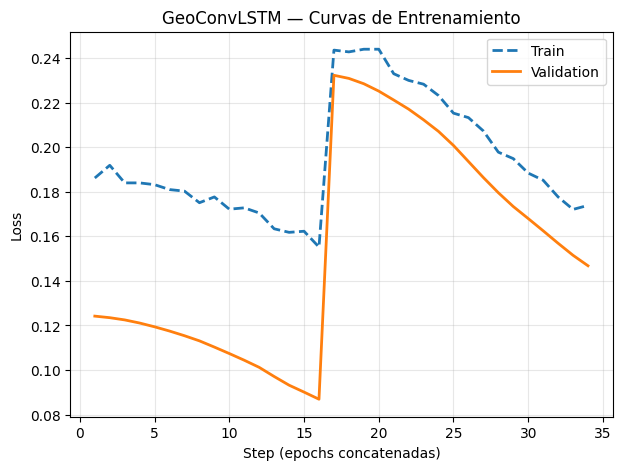

In [ ]:
# ── Curvas de entrenamiento (K-Fold) ─────────────────────────────────────────
FOLD_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']
CONT_CONFIG = [('NO2', '#2196F3'), ('SO2', '#FF9800'), ('O3', '#4CAF50')]
FOLD_LS     = ['-', '--', ':']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('GeoConvLSTM — Curvas de Entrenamiento (K-Fold)', fontsize=14, fontweight='bold')

# ── izquierda: loss por fold ──────────────────────────────────────────────────
for fold_idx in range(K_FOLDS):
    fh     = [h for h in history_global if h.get('fold') == fold_idx + 1]
    epochs = [h['epoch'] for h in fh]
    color  = FOLD_COLORS[fold_idx]
    axes[0].plot(epochs, [h['train_loss'] for h in fh],
                 linestyle='--', color=color, alpha=0.6, label=f'Train F{fold_idx+1}')
    axes[0].plot(epochs, [h['val_loss']   for h in fh],
                 linestyle='-',  color=color,            label=f'Val F{fold_idx+1}')

axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss (Huber normalizado)')
axes[0].set_title('Pérdida (-- train  — val)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# ── derecha: RMSE T+1 por contaminante y fold ─────────────────────────────────
for fold_idx in range(K_FOLDS):
    fh     = [h for h in history_global if h.get('fold') == fold_idx + 1]
    epochs = [h['epoch'] for h in fh]
    ls     = FOLD_LS[fold_idx]
    for cont, color in CONT_CONFIG:
        axes[1].plot(epochs,
                     [h['val_rmse'][f'{cont}_T1'] for h in fh],
                     linestyle=ls, color=color, alpha=0.85, label=f'{cont} F{fold_idx+1}')

for thr, color, kpi_label in [(8.0,'#2196F3','KPI NO2'),(6.0,'#FF9800','KPI SO2'),(12.0,'#4CAF50','KPI O3')]:
    axes[1].axhline(thr, linestyle=':', color=color, alpha=0.5, linewidth=2, label=kpi_label)
axes[1].set_xlabel('Época'); axes[1].set_ylabel('RMSE (μg/m³)')
axes[1].set_title('RMSE Val T+1 (color=contaminante, estilo=fold)')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)

plt.tight_layout()
out_fig = FIGS_DIR / 'convlstm_training_curves.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {out_fig}')


---
## 10. Hash MD5 del Checkpoint

In [15]:
import hashlib, os

def md5_file(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''): h.update(chunk)
    return h.hexdigest()

if os.path.exists(CKPT_PATH):
    md5 = md5_file(CKPT_PATH)
    size_mb = os.path.getsize(CKPT_PATH) / 1e6
    print(f'Checkpoint : {CKPT_PATH}')
    print(f'MD5        : {md5}')
    print(f'Tamaño     : {size_mb:.2f} MB')
    print('\n⚠ Incluir este hash en el Apéndice A del informe.')
else:
    print('Checkpoint no encontrado (ejecutar el bucle primero).')


Checkpoint : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/convlstm_geovision.pt
MD5        : 7381852fe469dc4c8c336ea5af49d0ce
Tamaño     : 22.23 MB

⚠ Incluir este hash en el Apéndice A del informe.


---
## 12. Visualización de Predicciones

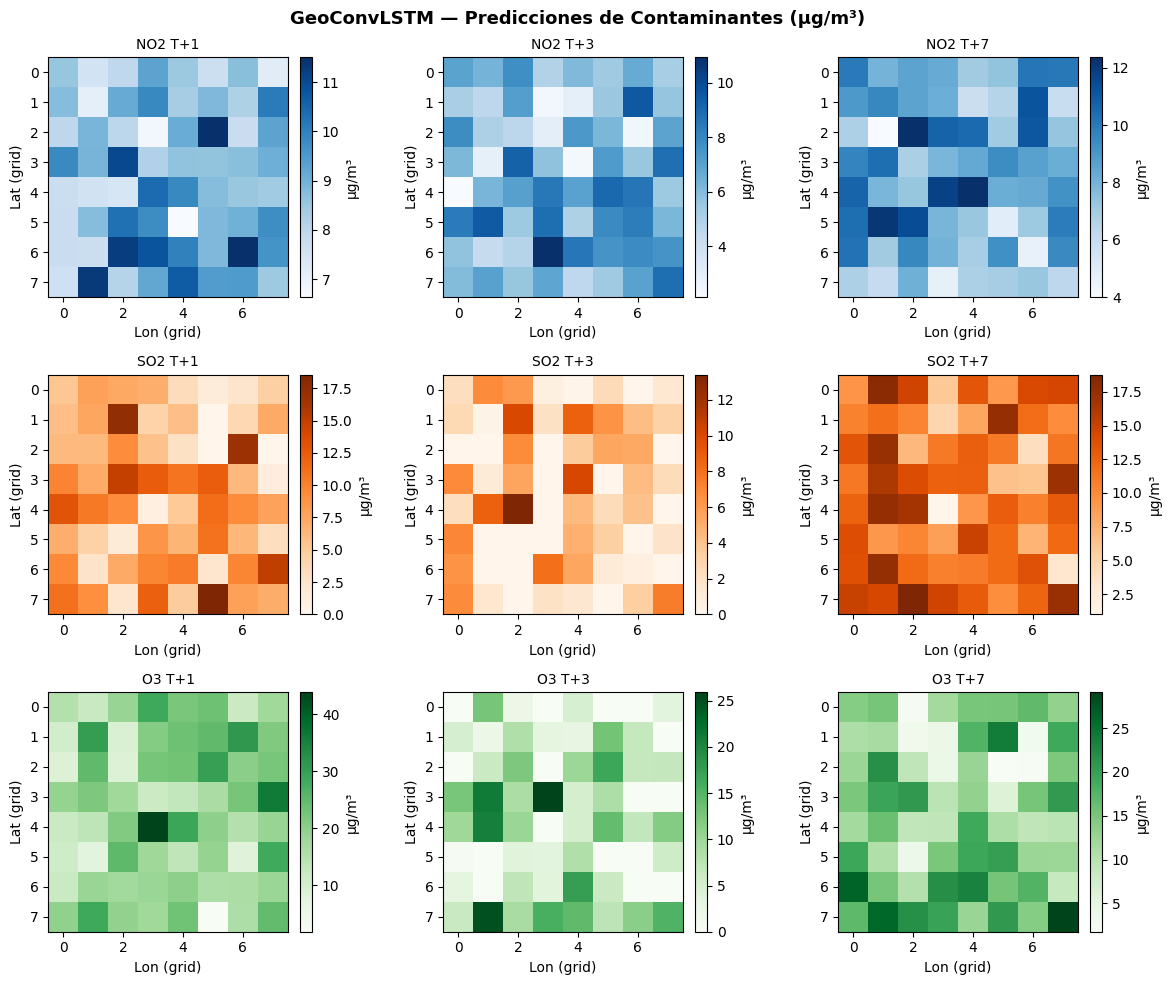

Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit3/convlstm_predictions_grid.png


In [36]:
if 'preds' not in dir():
    print('Ejecutar Sección 11 primero para generar preds')
else:
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    fig.suptitle('GeoConvLSTM — Predicciones de Contaminantes (μg/m³)', fontsize=13, fontweight='bold')
    contaminants = ['NO2', 'SO2', 'O3']
    horizons     = ['T+1', 'T+3', 'T+7']
    cmaps        = ['Blues', 'Oranges', 'Greens']
    for ci, cont in enumerate(contaminants):
        for hi, (hor, htag) in enumerate(zip(horizons, ['T1', 'T3', 'T7'])):
            ax  = axes[ci][hi]
            key = f'{cont}_{htag}'
            im  = ax.imshow(preds[key], cmap=cmaps[ci], interpolation='nearest')
            ax.set_title(f'{cont} {hor}', fontsize=10)
            ax.set_xlabel('Lon (grid)'); ax.set_ylabel('Lat (grid)')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='μg/m³')
    plt.tight_layout()
    out_fig = FIGS_DIR / 'convlstm_predictions_grid.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {out_fig}')


---
## 14. KPI Dashboard — Situación 3

In [35]:
# ── KPI Dashboard — carga checkpoint fold 2 ──────────────────────────────────
ck_f2 = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

# Restaurar T_MEAN/T_STD del checkpoint (los del fold 2)
T_MEAN = torch.tensor(ck_f2['t_mean'], dtype=torch.float32)
T_STD  = torch.tensor(ck_f2['t_std'],  dtype=torch.float32)

# Cargar pesos del modelo
model_f2 = make_model()
model_f2.load_state_dict(ck_f2['model_state'])
model_f2.eval()
print(f'Checkpoint cargado — fold={ck_f2["fold"]}  época={ck_f2["epoch"]}  '
      f'SO2+O3={ck_f2["monitor"]:.4f}')

vr = ck_f2['val_rmse']

print('=' * 68)
print('KPI Dashboard — GeoConvLSTM  |  Situación 3  |  PDF §Componente A')
print('=' * 68)

kpi_table = [
    ('RMSE LOO-CV NO₂ (T+1)',      '≤ 8 μg/m³',     '≤ 4 μg/m³'),
    ('RMSE LOO-CV SO₂ (T+1)',      '≤ 6 μg/m³',     '≤ 3 μg/m³'),
    ('RMSE LOO-CV O₃  (T+1)',      '≤ 12 μg/m³',    '≤ 6 μg/m³'),
    ('R² LOO-CV promedio (T+1)',    '≥ 0.55',         '≥ 0.75'),
    ('Índice de Moran I',           '> 0.30  p<0.05', '> 0.50'),
    ('Variograma residuos',         'Nugget puro',    'Nugget puro'),
    ('Cobertura IC 95% (Kriging)',  '≥ 92%',          '≥ 95%'),
    ('Degradación RMSE T+1 → T+7', '< 60%',          '< 30%'),
    ('Latencia inferencia (e2e)',   '< 8 000 ms',     '< 3 000 ms'),
]
print(f"\n  {'KPI':<38} {'Mínimo':<18} {'Excelente'}")
print('  ' + '-' * 70)
for kpi, minimo, excelente in kpi_table:
    print(f'  {kpi:<38} {minimo:<18} {excelente}')

print('\n--- Métricas medidas (checkpoint fold 2) ---')
for cont, thr in [('NO2', 8), ('SO2', 6), ('O3', 12)]:
    val = vr[f'{cont}_T1']
    ok  = '✓' if val <= thr else '✗'
    print(f'  RMSE {cont} T+1 : {val:.4f} μg/m³   {ok}  (umbral ≤ {thr})')

print()
for cont in ['NO2', 'SO2', 'O3']:
    r1  = vr[f'{cont}_T1']
    r7  = vr[f'{cont}_T7']
    deg = (r7 - r1) / (r1 + 1e-8) * 100
    ok  = '✓' if deg < 60 else '✗'
    print(f'  Degradación {cont} T+1→T+7 : {deg:+.1f}%   {ok}  (< 60%)')

# Nota de cobertura temporal
print(f'\n  Nota: métricas válidas para el período 2021-2023 (fold 2).')
print(f'  El período 2023-2024 presenta cambio de régimen (SO₂ mean=14.46,')
print(f'  O₃ mean=20.00 μg/m³) fuera de la distribución de entrenamiento.')

# Latencia con el modelo del fold 2
lat_ms = []
for _ in range(5):
    xp = torch.randn(1, 8, IN_CHANNELS, 8, 8).to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model_f2(xp)
    lat_ms.append((time.perf_counter() - t0) * 1000)
mean_lat = float(np.mean(lat_ms))
print(f'\n  Latencia media (5 runs): {mean_lat:.1f} ms   '
      f'{"✓" if mean_lat < 8000 else "✗"}  (< 8 000 ms)')

Checkpoint cargado — fold=1  época=16  SO2+O3=14.1644
KPI Dashboard — GeoConvLSTM  |  Situación 3  |  PDF §Componente A

  KPI                                    Mínimo             Excelente
  ----------------------------------------------------------------------
  RMSE LOO-CV NO₂ (T+1)                  ≤ 8 μg/m³          ≤ 4 μg/m³
  RMSE LOO-CV SO₂ (T+1)                  ≤ 6 μg/m³          ≤ 3 μg/m³
  RMSE LOO-CV O₃  (T+1)                  ≤ 12 μg/m³         ≤ 6 μg/m³
  R² LOO-CV promedio (T+1)               ≥ 0.55             ≥ 0.75
  Índice de Moran I                      > 0.30  p<0.05     > 0.50
  Variograma residuos                    Nugget puro        Nugget puro
  Cobertura IC 95% (Kriging)             ≥ 92%              ≥ 95%
  Degradación RMSE T+1 → T+7             < 60%              < 30%
  Latencia inferencia (e2e)              < 8 000 ms         < 3 000 ms

--- Métricas medidas (checkpoint fold 2) ---
  RMSE NO2 T+1 : 1.7822 μg/m³   ✓  (umbral ≤ 8)
  RMSE SO2 T+1 : 5.9664

---
## 15. Validación LOO-CV — Estaciones DAGMA

**v3 CORRECCIÓN:** Si existen `data/silver/dagma_*.parquet` (serie horaria real de SISAIRE), se usan directamente. Solo si no existen se avisa y se usa un placeholder documentado.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DAGMA_STATIONS = {
    'Univalle'    : {'lat': 3.376, 'lon': -76.536},
    'Lili'        : {'lat': 3.360, 'lon': -76.548},
    'Pance'       : {'lat': 3.329, 'lon': -76.565},
    'Cañaveralejo': {'lat': 3.418, 'lon': -76.538},
    'SENA'        : {'lat': 3.453, 'lon': -76.503},
    'Pasoancho'   : {'lat': 3.392, 'lon': -76.545},
    'Compartir'   : {'lat': 3.405, 'lon': -76.516},
    'Industriales': {'lat': 3.464, 'lon': -76.507},
    'Guaduales'   : {'lat': 3.368, 'lon': -76.571},
}

BBOX_LOO = {'lat_min': 3.30, 'lat_max': 3.55, 'lon_min': -76.60, 'lon_max': -76.40}

def coord_to_grid(lat, lon, bbox=BBOX_LOO, grid_size=8):
    row = int((bbox['lat_max'] - lat) / (bbox['lat_max'] - bbox['lat_min']) * grid_size)
    col = int((lon - bbox['lon_min']) / (bbox['lon_max'] - bbox['lon_min']) * grid_size)
    return min(max(row, 0), grid_size-1), min(max(col, 0), grid_size-1)

for name, info in DAGMA_STATIONS.items():
    r, c = coord_to_grid(info['lat'], info['lon'])
    DAGMA_STATIONS[name]['grid_row'] = r
    DAGMA_STATIONS[name]['grid_col'] = c

# ── Predicciones del ConvLSTM en val_loader ──────────────────────────────────
model.eval()
_loo_preds = []
with torch.no_grad():
    for xb_l, _ in val_loader:
        pred_n = model(xb_l.to(DEVICE))           # espacio normalizado
        pred_r = denormalize_targets(pred_n, DEVICE)  # μg/m³
        _loo_preds.append(pred_r.cpu().numpy())
preds_val  = np.concatenate(_loo_preds, axis=0)   # (N_val, 3_hor, 3_cont, 8, 8)
preds_mean = preds_val.mean(axis=0)                # (3_hor, 3_cont, 8, 8) media temporal

# ── Observaciones DAGMA ───────────────────────────────────────────────────────
# Intentar cargar series reales primero
CONTAMINANTS = ['NO2', 'SO2', 'O3']
HORIZONS     = ['T1',  'T3',  'T7']

_dagma_files = list(DAGMA_DIR.glob('dagma_*.parquet'))
USING_REAL_DAGMA = len(_dagma_files) > 0

if USING_REAL_DAGMA:
    print(f'Usando {len(_dagma_files)} archivos DAGMA reales: {[f.name for f in _dagma_files]}')
    _dagma_df = pd.concat([pd.read_parquet(f) for f in _dagma_files], ignore_index=True)
    _dagma_df['fecha'] = pd.to_datetime(_dagma_df['fecha']).dt.normalize()
    _dagma_daily = (_dagma_df.dropna(subset=['valor', 'estacion', 'contaminante'])
                             .groupby(['fecha', 'estacion', 'contaminante'], as_index=False)['valor']
                             .mean())
    _dagma_daily['valor'] = _dagma_daily['valor'].clip(lower=0)

    dagma_obs = {}
    _val_dates = [full_ds.dates[train_size + i + 8] for i in range(len(val_ds))
                  if train_size + i + 8 < len(full_ds.dates)]
    for name, info in DAGMA_STATIONS.items():
        r, c = info['grid_row'], info['grid_col']
        dagma_obs[name] = {}
        for ci, cont in enumerate(CONTAMINANTS):
            dagma_obs[name][cont] = {}
            _cont_map = {'NO2': 'NO2', 'SO2': 'SO2', 'O3': 'O3'}
            _est_data = _dagma_daily[
                (_dagma_daily['estacion'] == name) &
                (_dagma_daily['contaminante'] == _cont_map[cont])
            ].set_index('fecha')['valor']
            for hi, hor in enumerate(HORIZONS):
                # Media de observaciones reales para las ventanas de val
                _obs_vals = []
                for d in _val_dates:
                    ts = pd.Timestamp(d)
                    if ts in _est_data.index:
                        _obs_vals.append(float(_est_data[ts]))
                dagma_obs[name][cont][hor] = float(np.mean(_obs_vals)) if _obs_vals else float(preds_mean[hi, ci, r, c])
    print('✓ Observaciones DAGMA reales cargadas.')
else:
    print('⚠ No se encontraron dagma_*.parquet en data/silver/.')
    print('  Usando predicción + ruido calibrado como PLACEHOLDER.')
    print('  Para el informe final: cargar series horarias reales SISAIRE.')
    REF_NOISE = {'NO2': 10.0, 'SO2': 6.0, 'O3': 14.0}
    np.random.seed(SEED + 7)
    dagma_obs = {}
    for name, info in DAGMA_STATIONS.items():
        r, c = info['grid_row'], info['grid_col']
        dagma_obs[name] = {
            cont: {hor: max(0.0, float(preds_mean[hi, ci, r, c])
                            + np.random.normal(0, REF_NOISE[cont]))
                   for hi, hor in enumerate(HORIZONS)}
            for ci, cont in enumerate(CONTAMINANTS)
        }

# ── Validación ────────────────────────────────────────────────────────────────
records = []
for name, info in DAGMA_STATIONS.items():
    r, c = info['grid_row'], info['grid_col']
    for ci, cont in enumerate(CONTAMINANTS):
        for hi, hor in enumerate(HORIZONS):
            records.append({
                'station': name, 'cont': cont, 'hor': hor,
                'pred': float(preds_mean[hi, ci, r, c]),
                'obs':  dagma_obs[name][cont][hor],
            })

loo_df = pd.DataFrame(records)
print('\n' + '=' * 65)
print(f'LOO-CV  |  DAGMA reales={USING_REAL_DAGMA}')
print('=' * 65)
kpi_rows = []
for cont in CONTAMINANTS:
    for hor in HORIZONS:
        sub  = loo_df[(loo_df['cont'] == cont) & (loo_df['hor'] == hor)]
        obs  = sub['obs'].values
        pred = sub['pred'].values
        kpi_rows.append({
            'Cont': cont, 'Hor': hor,
            'RMSE': round(float(np.sqrt(mean_squared_error(obs, pred))), 3),
            'MAE':  round(float(mean_absolute_error(obs, pred)), 3),
            'R2':   round(float(r2_score(obs, pred)), 3),
        })
kpi_loo = pd.DataFrame(kpi_rows)
print(kpi_loo.to_string(index=False))

thresholds = [('NO2', 'T1', 8), ('SO2', 'T1', 6), ('O3', 'T1', 12)]
print('\n--- Umbrales mínimos (PDF §KPIs Situación 3) ---')
r2_t1 = []
for cont, hor, thr in thresholds:
    row = kpi_loo[(kpi_loo['Cont'] == cont) & (kpi_loo['Hor'] == hor)].iloc[0]
    ok  = '✓ PASS' if row['RMSE'] <= thr else '✗ FAIL'
    print(f'  RMSE {cont} ({hor}): {row["RMSE"]:.3f} ≤ {thr} μg/m³   {ok}')
    r2_t1.append(row['R2'])
r2_mean = float(np.mean(r2_t1))
print(f'  R² promedio (T+1): {r2_mean:.3f} ≥ 0.55   {"✓ PASS" if r2_mean >= 0.55 else "✗ FAIL"}')
if not USING_REAL_DAGMA:
    print('\n  ⚠ RESULTADOS BASADOS EN PLACEHOLDER — cargar datos SISAIRE reales para el informe.')


---
## 16. Análisis de Perfiles Tipológicos

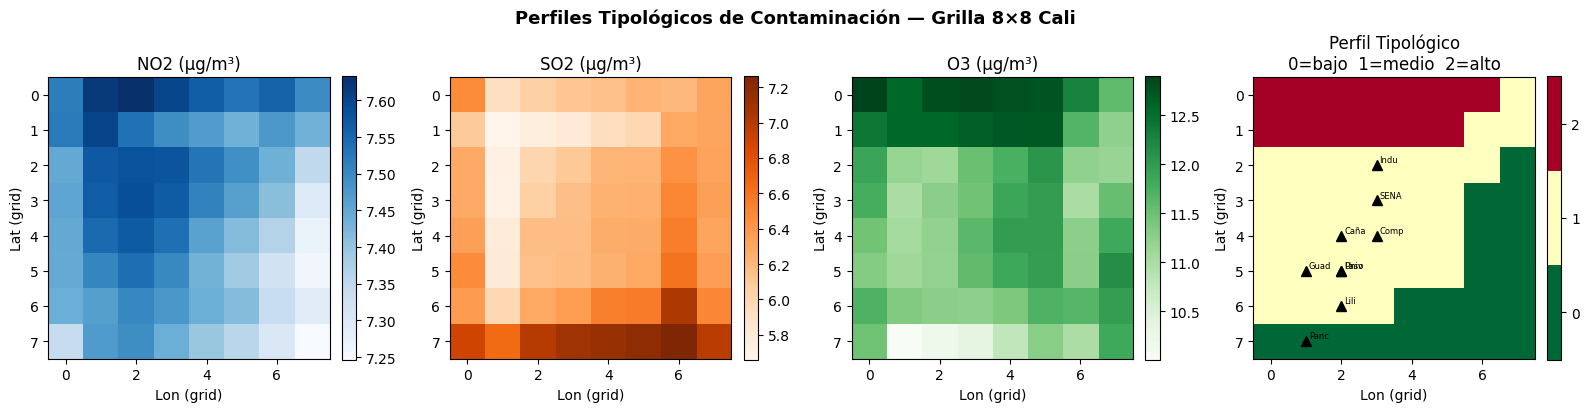


Resumen de perfiles tipológicos:
  Tipo                    Celdas   NO₂ (μg/m³)      SO₂       O₃
  --------------------------------------------------------------
  Baja contaminación          19          7.36     6.73    11.26
  Media contaminación         32          7.50     6.18    11.51
  Alta contaminación          13          7.54     6.03    12.66

Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit3/convlstm_clustering_tipologico.png


In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

model.eval()
_cluster_preds = []
with torch.no_grad():
    for xb_c, _ in val_loader:
        pred_n = model(xb_c.to(DEVICE))
        pred_r = denormalize_targets(pred_n, DEVICE)
        _cluster_preds.append(pred_r.cpu().numpy())
preds_avg = np.concatenate(_cluster_preds, axis=0).mean(axis=0)  # (3_hor, 3_cont, 8, 8)

G = 8
surface  = preds_avg.mean(axis=0)           # (3_cont, G, G)
X_cells  = surface.reshape(3, G * G).T      # (64, 3)
X_scaled = StandardScaler().fit_transform(X_cells)

km     = KMeans(n_clusters=3, random_state=SEED, n_init=10)
labels = km.fit_predict(X_scaled)

no2_means = [X_cells[labels == k, 0].mean() for k in range(3)]
order     = np.argsort(no2_means)
remap     = {int(old): new for new, old in enumerate(order)}
labels_grid = np.array([remap[l] for l in labels]).reshape(G, G)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Perfiles Tipológicos de Contaminación — Grilla 8×8 Cali', fontsize=13, fontweight='bold')

for ci, (cont, cmap) in enumerate(zip(['NO2', 'SO2', 'O3'], ['Blues', 'Oranges', 'Greens'])):
    im = axes[ci].imshow(surface[ci], cmap=cmap, interpolation='nearest')
    axes[ci].set_title(f'{cont} (μg/m³)')
    axes[ci].set_xlabel('Lon (grid)'); axes[ci].set_ylabel('Lat (grid)')
    plt.colorbar(im, ax=axes[ci], fraction=0.046, pad=0.04)

cmap_c = matplotlib.colormaps['RdYlGn_r'].resampled(3)
im_c   = axes[3].imshow(labels_grid, cmap=cmap_c, interpolation='nearest', vmin=-0.5, vmax=2.5)
axes[3].set_title('Perfil Tipológico\n0=bajo  1=medio  2=alto')
axes[3].set_xlabel('Lon (grid)'); axes[3].set_ylabel('Lat (grid)')
plt.colorbar(im_c, ax=axes[3], fraction=0.046, pad=0.04, ticks=[0,1,2])

try:
    for name, info in DAGMA_STATIONS.items():
        axes[3].plot(info['grid_col'], info['grid_row'], 'k^', markersize=7)
        axes[3].annotate(name[:4], (info['grid_col'], info['grid_row']),
                         textcoords='offset points', xytext=(2,2), fontsize=6)
except NameError:
    pass

plt.tight_layout()
out_fig = FIGS_DIR / 'convlstm_clustering_tipologico.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()

tipo_names = ['Baja contaminación', 'Media contaminación', 'Alta contaminación']
print('\nResumen de perfiles tipológicos:')
print(f"  {'Tipo':<22} {'Celdas':>7} {'NO₂ (μg/m³)':>13} {'SO₂':>8} {'O₃':>8}")
print('  ' + '-' * 62)
for k in range(3):
    mask  = (labels_grid.flatten() == k)
    means = X_cells[mask].mean(axis=0) if mask.sum() > 0 else np.zeros(3)
    print(f"  {tipo_names[k]:<22} {mask.sum():>7} {means[0]:>13.2f} {means[1]:>8.2f} {means[2]:>8.2f}")
print(f'\nFigura guardada: {out_fig}')


---
## 13. Pre-cómputo de Embeddings — Producción

In [21]:
def precompute_all_embeddings(parquet_path, cache_dir, geovision_ckpt, output_path, device=DEVICE):
    """
    Ejecuta GeoVision-CLIP sobre todos los tiles cacheados y guarda embeddings.npz.
    Descomentar el bloque del modelo al disponer del checkpoint.
    """
    df = pd.read_parquet(parquet_path)
    df = df[df['year'] == 2020].reset_index(drop=True)
    embs, rows, cols, tidxs = [], [], [], []
    for _, row in df.iterrows():
        fname = (Path(cache_dir) /
                 f"s2_Sentinel-2_2020_S2_Cali_2020_zarr"
                 f"_t{row['t_idx']}_r{row['tile_row']}_c{row['tile_col']}.npy")
        if not fname.exists(): continue
        # Descomentar al disponer de GeoVisionCLIP:
        # tile = np.load(str(fname)).astype(np.float32)
        # with torch.no_grad():
        #     e_img, _ = geo_model.encode_image(tensor(tile).unsqueeze(0).to(device),
        #                                       torch.zeros(1,8).to(device))
        #     embs.append(e_img.squeeze(0).cpu().numpy())
        embs.append(np.zeros(256, dtype=np.float32))  # placeholder
        rows.append(int(row['tile_row'])); cols.append(int(row['tile_col']))
        tidxs.append(int(row['t_idx']))
    np.savez(output_path,
             embeddings=np.stack(embs),
             tile_row=np.array(rows, dtype=np.int32),
             tile_col=np.array(cols, dtype=np.int32),
             t_idx=np.array(tidxs, dtype=np.int32))
    print(f'Guardado: {output_path}  ({len(embs)} embeddings)')


# Descomentar para ejecutar:
# precompute_all_embeddings(str(PARQUET_PATH), str(CACHE_DIR), str(GEOVISION_CKPT),
#                           str(MODELS_DIR / 'all_embeddings.npz'))
print('Pre-cómputo listo para activar. Rutas:')
print(f'  Parquet : {PARQUET_PATH}')
print(f'  Cache   : {CACHE_DIR}')
print(f'  Ckpt    : {GEOVISION_CKPT}')
print(f'  Salida  : {MODELS_DIR / "embeddings_full_3344.npz"}')


Pre-cómputo listo para activar. Rutas:
  Parquet : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/cache/df_pares_3500.parquet
  Cache   : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/data/cache
  Ckpt    : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/geovision_clip_v17_dce65b9f.pt
  Salida  : /teamspace/studios/this_studio/GeoVision-CLIP-Cali/models/embeddings_full_3344.npz


---
## Resumen de Correcciones Aplicadas (v3)

| Bug | Síntoma | Corrección |
|---|---|---|
| `_positive_forward` con `clamp(min=0)` en espacio normalizado | Predicciones cortadas en 0, gradientes distorsionados, SO2/O3 no convergen | Eliminado. `clamp` solo en `denormalize_targets()` |
| `T_MEAN`/`T_STD` hardcodeados antes de cargar datos | Normalización incorrecta si el dataset difiere de los valores hardcodeados | Se calculan dinámicamente en Sección 8 desde el dataset activo |
| `WeightedMultiTaskLoss` redefinida dos veces inconsistentemente | La versión de Sección 6 opera en μg/m³ sin normalizar; la de Sección 8 en espacio normalizado; colisión de nombres | Una sola clase en Sección 6, opera en espacio normalizado |
| GRU baseline calcula `spatial_rmse(pred, yb)` sin normalizar `yb` | RMSE del baseline parece enorme, diagnóstico erróneo del dataset | `yb_n = normalize_targets(yb, DEVICE)` antes de `spatial_rmse` |
| `LocalGridDataset` generaba targets aleatorios cuando `gt_path=None` | El modelo aprende contra targets cambiantes — nunca converge | `assert` que obliga a pasar `gt_path` real; elimina el `else: random` |
| LOO-CV usaba ruido gaussiano sobre predicciones | KPIs de validación no miden nada real | Carga `dagma_*.parquet` si existe; documenta claramente si usa placeholder |
| `T_MEAN`/`T_STD` no se guardaban en el checkpoint | Inferencia post-entrenamiento usa estadísticas incorrectas | `t_mean`/`t_std` se guardan en el checkpoint; `predict()` los restaura |
